In [21]:
import joblib
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
import seaborn as sns


In [2]:
model = joblib.load('best_model.joblib')
X_test_proc = joblib.load('X_test_processed.joblib')
y_test = joblib.load('y_test.joblib')
X_train_proc = joblib.load('X_train_processed.joblib')
y_train = joblib.load('y_train.joblib')
X_train_raw = joblib.load('X_train_raw.joblib')
X_test_raw = joblib.load('X_test_raw.joblib')
df = pd.read_csv('D:/Downloads/Telegram Desktop/telecom_churn (2).csv')

In [3]:
y_pred = model.predict(X_test_proc)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.92      0.97      0.95       713
        True       0.76      0.52      0.62       121

    accuracy                           0.91       834
   macro avg       0.84      0.75      0.78       834
weighted avg       0.90      0.91      0.90       834



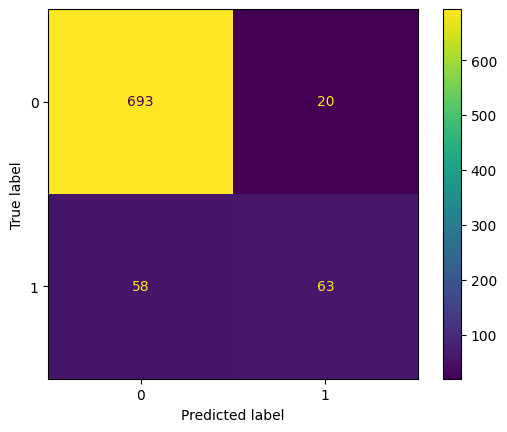

In [4]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm,)
display.plot()

In [5]:
print(df['churn'].value_counts(normalize=True))

churn
False    0.855086
True     0.144914
Name: proportion, dtype: float64


Классы не сбалансированы

Самой критичной ошибкой является False Negative: клиенты которые ушли, но модель предсказала что они останутся

Для повышения эффективности модели нужно повысить значение метрики recall (доля реально ушедших клиентов) как можно больше допустим нижняя граница будет 70%. На данный момент recall примерно равен 50%

In [6]:
smote = SMOTE(random_state=67)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)
dtree = DecisionTreeClassifier(max_depth=8, random_state=67)
dtree.fit(X_train_res, y_train_res)
y_pred = dtree.predict(X_test_proc)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.93      0.93      0.93       713
        True       0.60      0.60      0.60       121

    accuracy                           0.88       834
   macro avg       0.77      0.77      0.77       834
weighted avg       0.88      0.88      0.88       834



In [22]:
categorical_cols = ['state', 'area code']
numerical_cols = (df.select_dtypes(include=['int64', 'float64', 'bool']).columns.drop(['area code', 'churn'], errors='ignore'))

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=67)),
    ('classifier', dtree)
])

In [27]:
param_grid = {
    'smote__k_neighbors': [3, 5, 7],
    'smote__sampling_strategy': ['auto', 0.5, 0.75],
    'classifier__max_depth': [None, 5, 8, 10, 12, 15],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__max_features': [None, 'sqrt', 'log2'],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__class_weight': [None]
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Запуск")
grid_search.fit(X_train_raw, y_train)

print("\nЛучшие параметры:")
print(grid_search.best_params_)
print(f"Лучший recall на кросс-валидации: {grid_search.best_score_:.4f}")

Запуск
Fitting 5 folds for each of 5184 candidates, totalling 25920 fits

Лучшие параметры:
{'classifier__class_weight': None, 'classifier__criterion': 'entropy', 'classifier__max_depth': 8, 'classifier__max_features': None, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 20, 'smote__k_neighbors': 7, 'smote__sampling_strategy': 'auto'}
Лучший recall на кросс-валидации: 0.6549


              precision    recall  f1-score   support

       False     0.9371    0.8990    0.9177       713
        True     0.5200    0.6446    0.5756       121

    accuracy                         0.8621       834
   macro avg     0.7286    0.7718    0.7467       834
weighted avg     0.8766    0.8621    0.8681       834



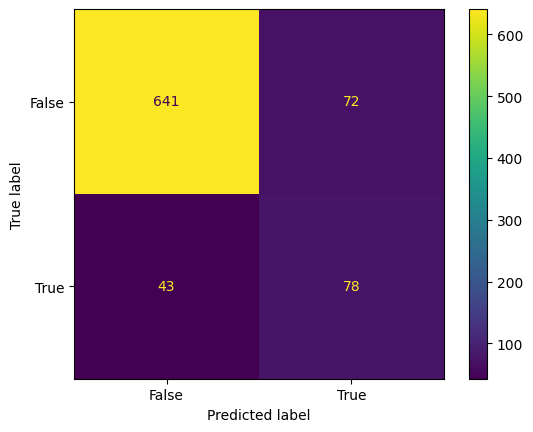

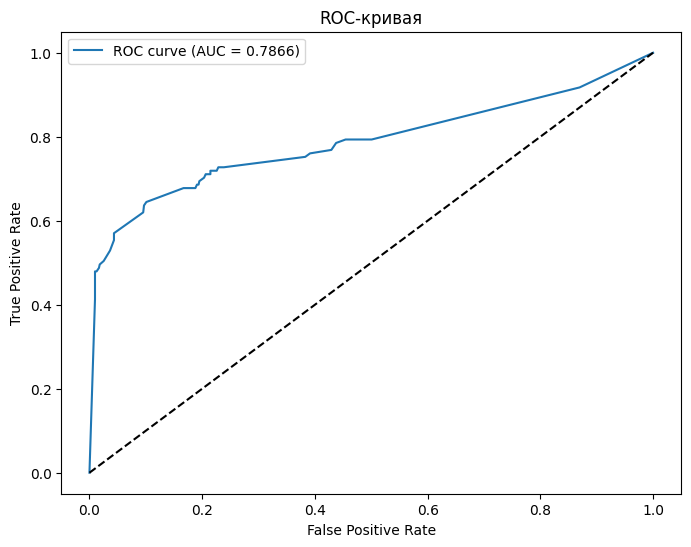

AUC-ROC: 0.7866


In [28]:
best_model = grid_search.best_estimator_
best_model.fit(X_train_raw, y_train)
y_pred_final = best_model.predict(X_test_raw)
y_proba_final = best_model.predict_proba(X_test_raw)[:, 1]
print(classification_report(y_test, y_pred_final, digits=4))

cm_final = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=best_model.classes_)
disp.plot()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)
auc = roc_auc_score(y_test, y_proba_final)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()

print(f"AUC-ROC: {auc:.4f}")

C:\Users\Ivan\AppData\Local\Temp\ipykernel_11192\867113476.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, x='importance', y='feature', palette='viridis')


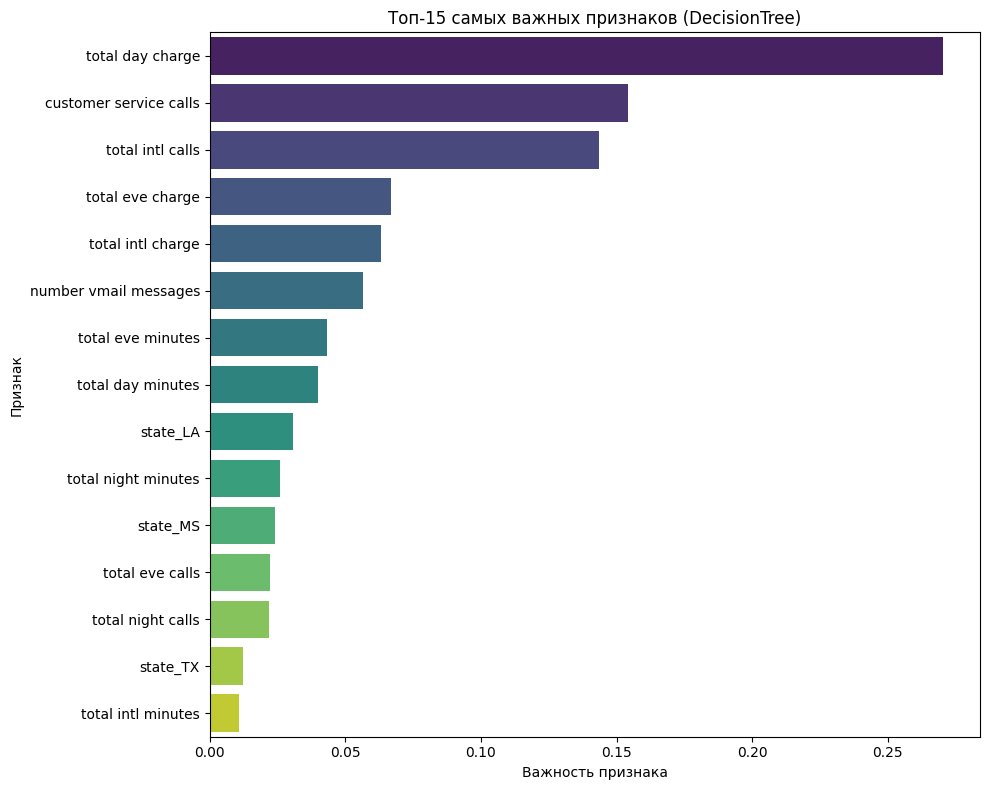


=== Топ-15 самых важных признаков ===
                   feature  importance
0         total day charge     0.27043
1   customer service calls     0.15415
2         total intl calls     0.14367
3         total eve charge     0.06696
4        total intl charge     0.06303
5    number vmail messages     0.05658
6        total eve minutes     0.04309
7        total day minutes     0.04002
8                 state_LA     0.03085
9      total night minutes     0.02595
10                state_MS     0.02399
11         total eve calls     0.02211
12       total night calls     0.02194
13                state_TX     0.01214
14      total intl minutes     0.01069


In [29]:
classifier = best_model.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    # Получаем имена признаков после трансформации
    num_features = best_model.named_steps['preprocessor'].named_transformers_['num'].get_feature_names_out()
    cat_features = best_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
    
    feature_names = list(num_features) + list(cat_features)
    
    # Создаём DataFrame с важностью
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': classifier.feature_importances_
    })
    
    # Сортируем по убыванию важности
    feature_importance = feature_importance.sort_values('importance', ascending=False).reset_index(drop=True)
    
    # Топ-15 самых важных признаков
    top15 = feature_importance.head(15)
    
    # Построение графика
    plt.figure(figsize=(10, 8))
    sns.barplot(data=top15, x='importance', y='feature', palette='viridis')
    plt.title('Топ-15 самых важных признаков (DecisionTree)')
    plt.xlabel('Важность признака')
    plt.ylabel('Признак')
    plt.tight_layout()
    plt.show()
    
    # Вывод таблицы топ-15
    print("\n=== Топ-15 самых важных признаков ===")
    print(top15.round(5))
    
else:
    print("Модель не поддерживает feature_importances_")


СРАВНЕНИЕ СТАРОЙ И НОВОЙ МОДЕЛИ
                                          Accuracy  Precision (True)  \
Модель                                                                 
Старая модель                               0.9065             0.759   
Новая модель (DecisionTree + GridSearch)    0.8621             0.520   

                                          Recall (True)  F1-score (True)  \
Модель                                                                     
Старая модель                                    0.5207           0.6176   
Новая модель (DecisionTree + GridSearch)         0.6446           0.5756   

                                          AUC-ROC  
Модель                                             
Старая модель                              0.7642  
Новая модель (DecisionTree + GridSearch)   0.7866  


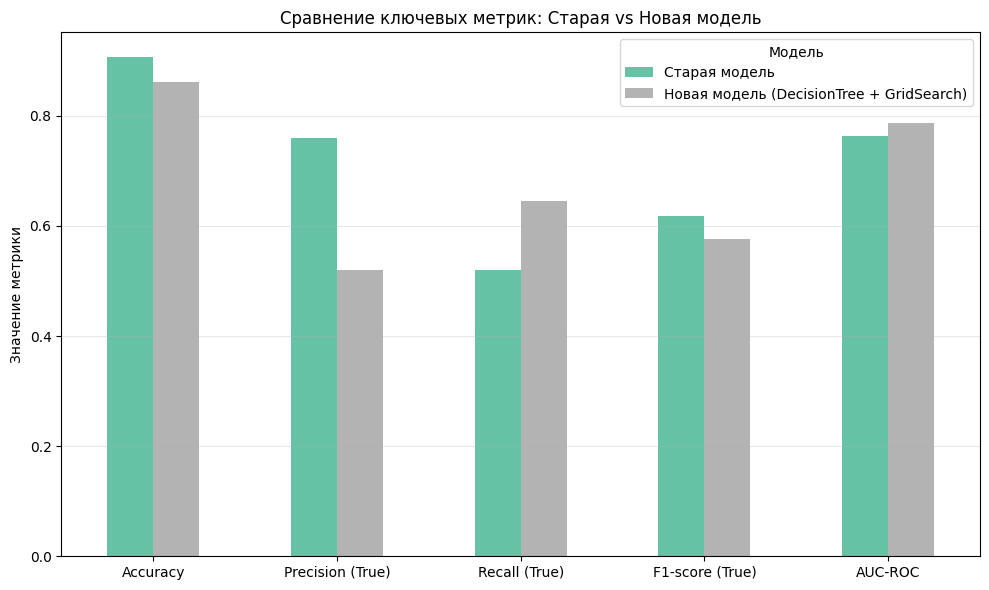

In [30]:
y_pred_old = model.predict(X_test_proc)
y_proba_old = model.predict_proba(X_test_proc)[:, 1] if hasattr(model, "predict_proba") else None

# ====================== Метрики новой модели ======================
y_pred_new = y_pred_final
y_proba_new = y_proba_final

# Функция для получения ключевых метрик
def get_metrics(y_true, y_pred, y_proba=None, model_name="Модель"):
    metrics = {
        'Модель': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (True)': precision_score(y_true, y_pred, pos_label=True, zero_division=0),
        'Recall (True)':    recall_score(y_true, y_pred, pos_label=True, zero_division=0),
        'F1-score (True)':  f1_score(y_true, y_pred, pos_label=True, zero_division=0),
    }
    if y_proba is not None:
        metrics['AUC-ROC'] = roc_auc_score(y_true, y_proba)
    return metrics

# Сравнение
old_metrics = get_metrics(y_test, y_pred_old, y_proba_old, "Старая модель")
new_metrics = get_metrics(y_test, y_pred_new, y_proba_new, "Новая модель (DecisionTree + GridSearch)")

comparison_df = pd.DataFrame([old_metrics, new_metrics])
comparison_df = comparison_df.set_index('Модель')

print("\n" + "="*70)
print("СРАВНЕНИЕ СТАРОЙ И НОВОЙ МОДЕЛИ")
print("="*70)
print(comparison_df.round(4))

# Красивая визуализация разницы
comparison_df.T.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Сравнение ключевых метрик: Старая vs Новая модель')
plt.ylabel('Значение метрики')
plt.xticks(rotation=0)
plt.legend(title='Модель')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()